In [19]:
from bs4 import BeautifulSoup,MarkupResemblesLocatorWarning
import requests
url="https://www.worldometers.info/world-population/nepal-population/"

In [20]:
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, "html.parser")
title = soup.title.string
table_code=soup.table

In [21]:
# table_code
tags=table_code.find_all('tr')
data_rows=[]

In [22]:

# for tag in tags:
#     data_rows.append(tag.text.strip())

In [23]:
# print(data_rows)

In [24]:
data_rows = []
for tag in tags:
    row = []
    cells = tag.find_all(['th', 'td'])
    
    for cell in cells:
        clean_text = cell.text.strip()
        row.append(clean_text)
    if row:
        data_rows.append(row)



In [25]:
# # Result print 
# for r in data_rows:
#     print(r)

In [26]:
import csv

filename = 'nepal_population.csv'
with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(data_rows)

print(f'CSV saved: {filename}')

CSV saved: nepal_population.csv


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('nepal_population.csv')

In [28]:
# df.head()

In [29]:
# df.columns = data_rows[0]
# print(df.columns)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('nepal_population.csv')

df['Year'] = df['Year'].astype(int)
df['Population'] = df['Population'].str.replace(',', '').astype(int)
df['Urban Population'] = df['Urban Population'].str.replace(',', '').astype(int)
df['Fertility Rate'] = df['Fertility Rate'].astype(float)
df['Median Age'] = df['Median Age'].astype(float)
df = df.sort_values('Year').reset_index(drop=True)


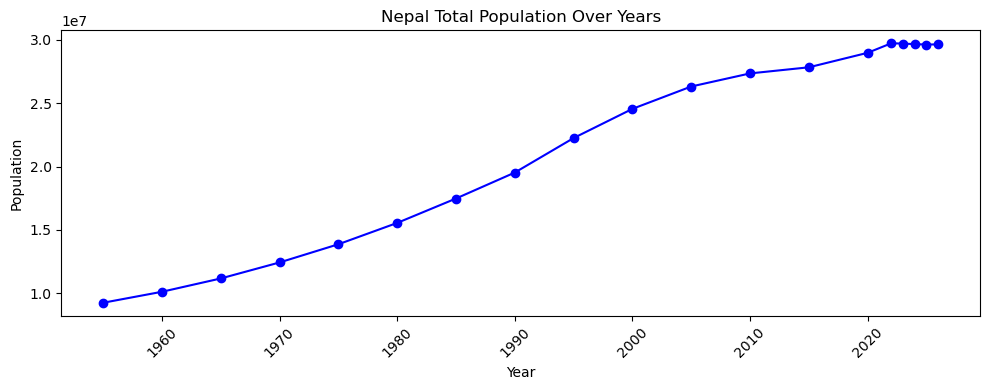

In [31]:
# 1. Line Plot - Total Population
plt.figure(figsize=(10, 4))
plt.plot(df['Year'], df['Population'], marker='o', color='blue')
plt.title('Nepal Total Population Over Years')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


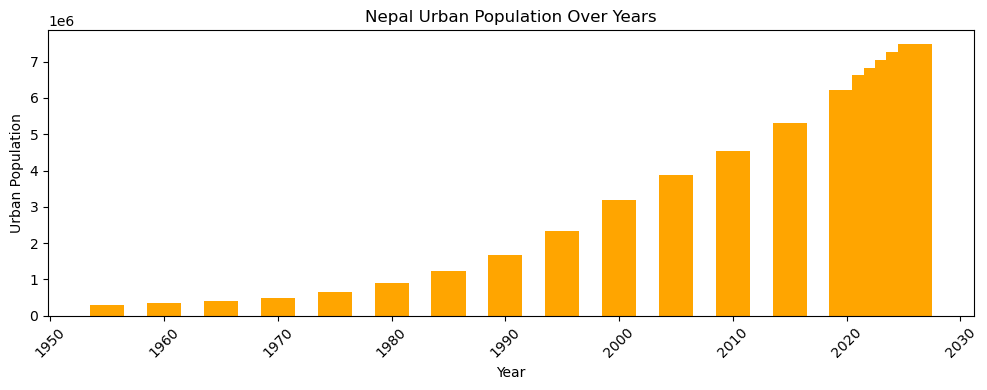

In [32]:
# 2. Bar Plot - Urban Population
plt.figure(figsize=(10, 4))
plt.bar(df['Year'], df['Urban Population'], color='orange', width=3)
plt.title('Nepal Urban Population Over Years')
plt.xlabel('Year')
plt.ylabel('Urban Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


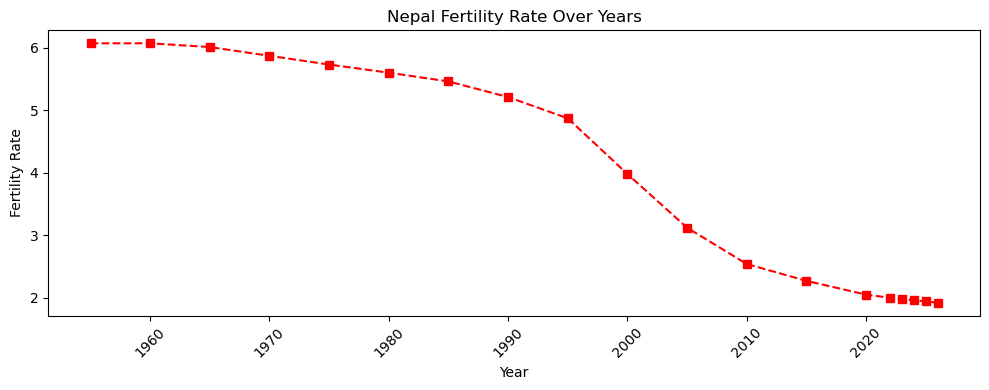

In [33]:
# 3. Line Plot - Fertility Rate
plt.figure(figsize=(10, 4))
plt.plot(df['Year'], df['Fertility Rate'], marker='s', color='red', linestyle='--')
plt.title('Nepal Fertility Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Fertility Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

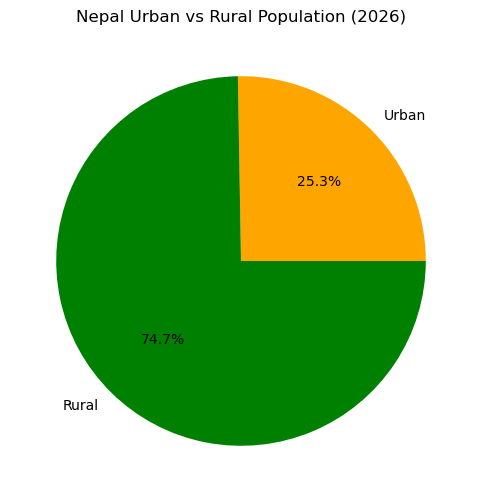

In [34]:
# 4. Pie Chart - Urban vs Rural Population (latest year)
latest = df.iloc[-1]
urban = latest['Urban Population']
rural = latest['Population'] - urban
plt.figure(figsize=(6, 6))
plt.pie([urban, rural], labels=['Urban', 'Rural'], autopct='%1.1f%%', colors=['orange', 'green'])
plt.title(f"Nepal Urban vs Rural Population ({int(latest['Year'])})")
plt.show()

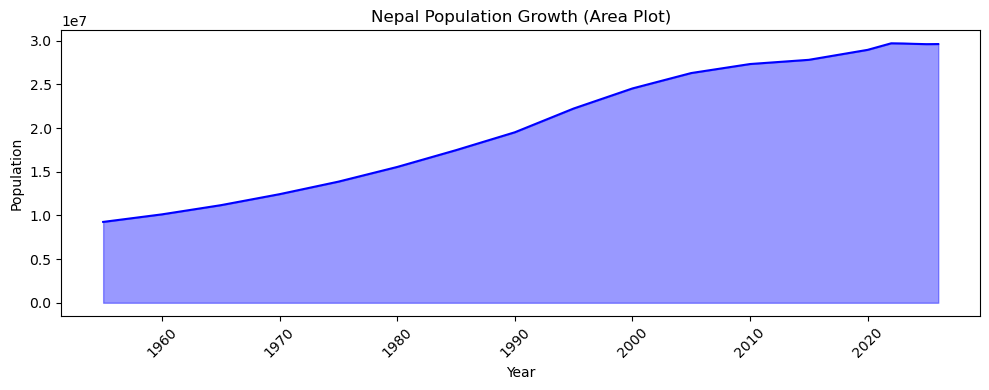

In [35]:
# 5. Area Plot - Population Growth
plt.figure(figsize=(10, 4))
plt.fill_between(df['Year'], df['Population'], alpha=0.4, color='blue')
plt.plot(df['Year'], df['Population'], color='blue')
plt.title('Nepal Population Growth (Area Plot)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


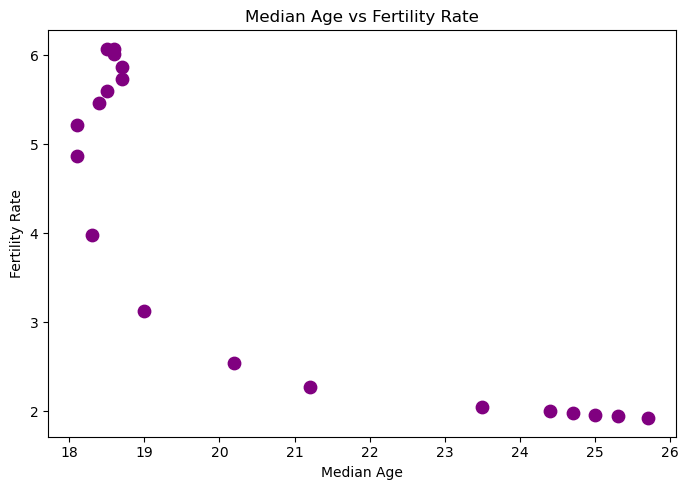

In [36]:
# 6. Scatter Plot - Median Age vs Fertility Rate
plt.figure(figsize=(7, 5))
plt.scatter(df['Median Age'], df['Fertility Rate'], color='purple', s=80)
plt.title('Median Age vs Fertility Rate')
plt.xlabel('Median Age')
plt.ylabel('Fertility Rate')
plt.tight_layout()
plt.show()